# Customer_Churn_Prediction

## Import libraries

In [10]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

## Load Dataset

In [89]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding 

In [90]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [91]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [92]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## Data Cleaning

In [93]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [94]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [95]:
df = df.drop('customerID', axis=1)

In [96]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


## EDA

In [98]:
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

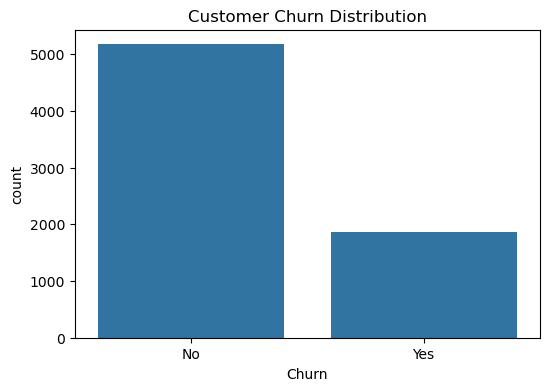

In [99]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [100]:
print(df['Contract'].value_counts())
df['Contract'].value_counts(normalize=True)

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

In [101]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


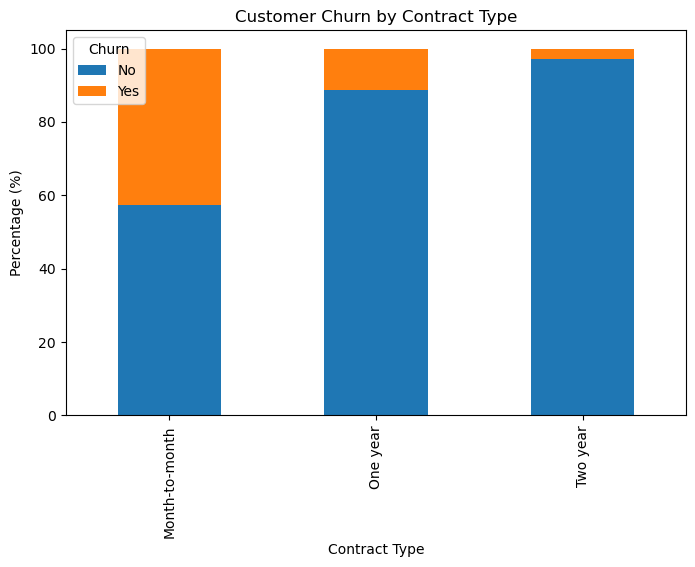

In [102]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

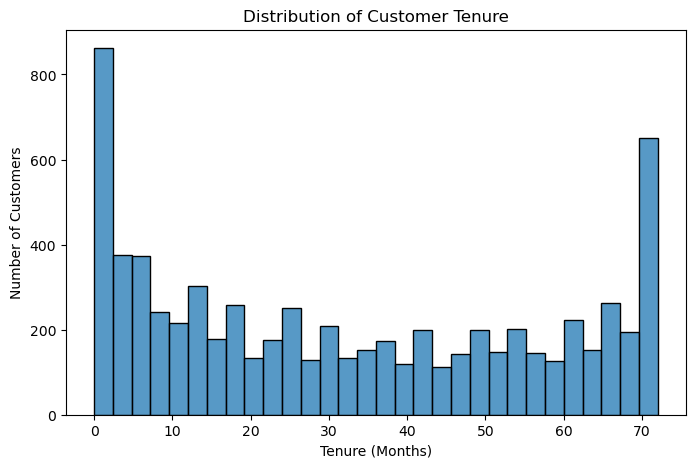

In [103]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

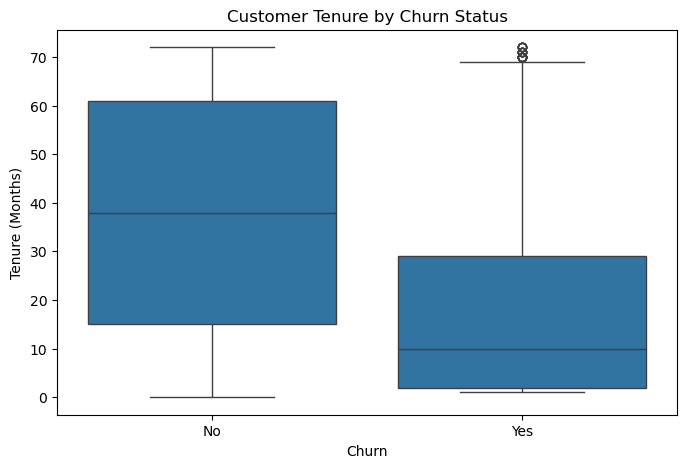

In [104]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [105]:
# Customer Churn by Partner

partner_churn_percentage = pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

partner_churn_percentage

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


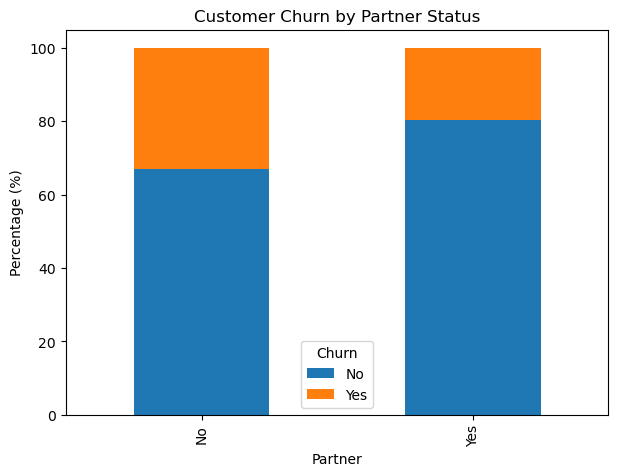

In [106]:
partner_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

In [107]:
internet_service_churn_percentage = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_service_churn_percentage

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


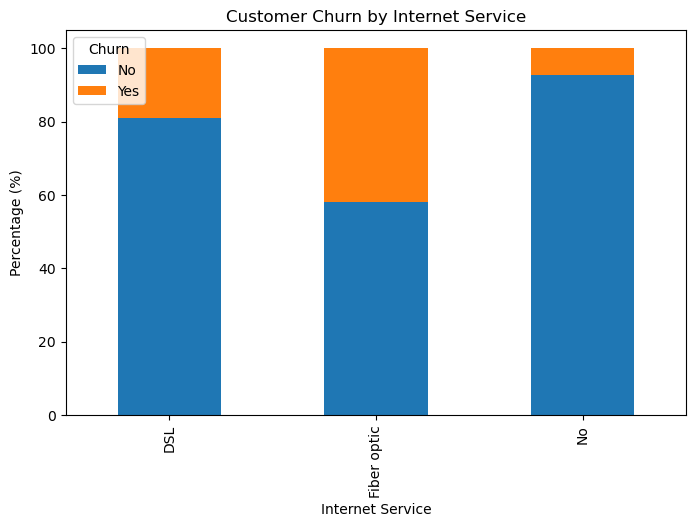

In [108]:
internet_service_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.show()

In [110]:
payment_method_churn_percentage = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_method_churn_percentage

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


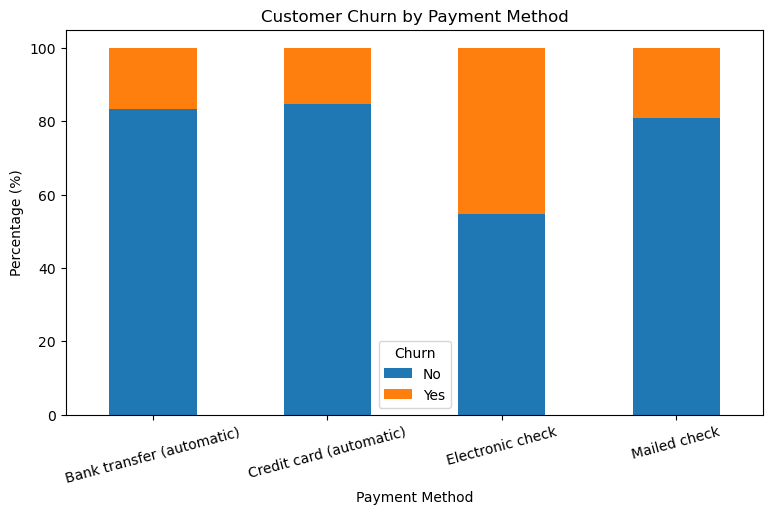

In [111]:
payment_method_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.xticks(rotation=15)

plt.show()

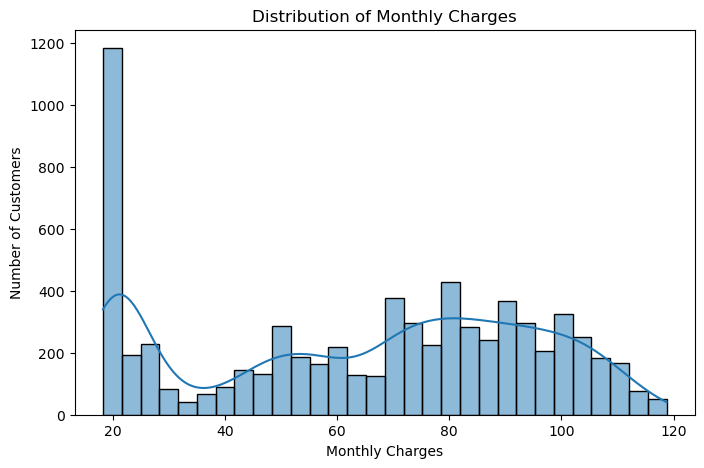

In [112]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

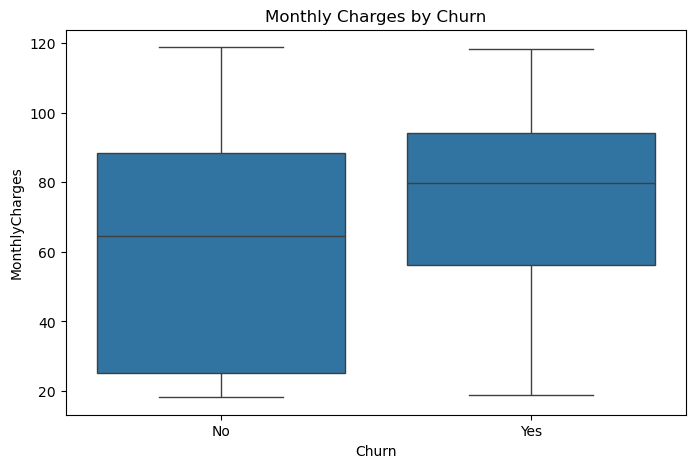

In [113]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges by Churn")


plt.show()

In [115]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])

numerical_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [116]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


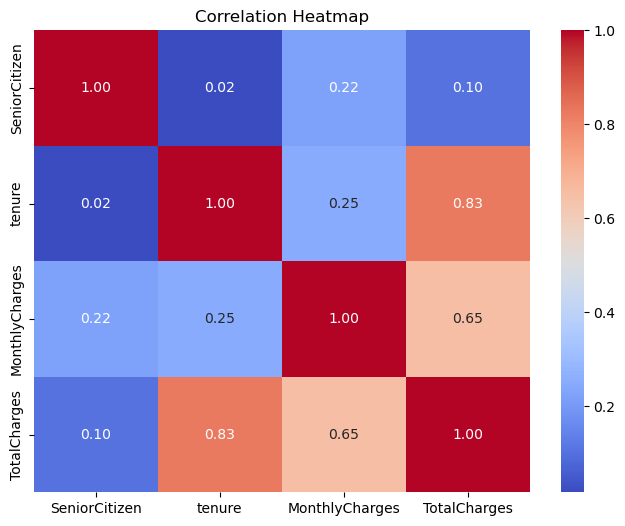

In [117]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

## Data Preprocessing

In [118]:
eplace_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in replace_cols:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [119]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

In [120]:
for col in binary_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0
    })

# Gender Encoding
df['gender'] = df['gender'].replace({
    'Male': 1,
    'Female': 0
})

In [121]:
# One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=[
        'InternetService',
        'Contract',
        'PaymentMethod'
    ],
    drop_first=True
)

In [127]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


##  Train-Test Split

In [128]:
# Features (Independent Variables)
X = df.drop('Churn', axis=1)

# Target (Dependent Variable)
y = df['Churn']

In [129]:
print(X.shape)

print(y.shape)

(7043, 23)
(7043,)


In [130]:
from sklearn.model_selection import train_test_split

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [131]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 23)
(1409, 23)
(5634,)
(1409,)


## Model Building

### Logistic Regression

In [132]:
from sklearn.linear_model import LogisticRegression

In [133]:
log_model = LogisticRegression(max_iter=1000)

In [73]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [74]:
y_pred = log_model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score

In [76]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 78.89%


In [77]:
from sklearn.metrics import confusion_matrix

In [78]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[918, 115],
       [182, 192]])

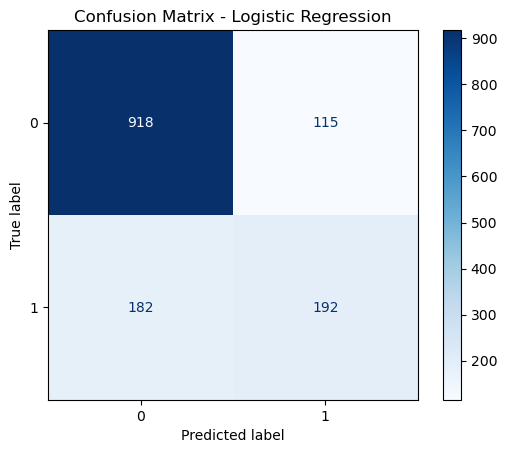

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Decision Tree

In [80]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 71.14%
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1033
           1       0.46      0.51      0.48       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.72      1407



### Random Forest

In [82]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 77.83%


## Model Comparison

In [83]:
comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison['Accuracy'] = comparison['Accuracy']*100

comparison

,Model,Accuracy
0,Logistic Regression,78.891258
1,Decision Tree,71.144279
2,Random Forest,77.825160


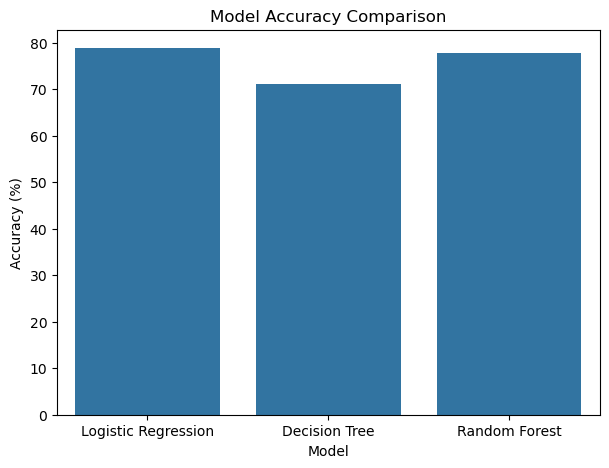

In [84]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

## Feature Importance

In [134]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
15,TotalCharges,0.191245
14,MonthlyCharges,0.180979
4,tenure,0.168698
16,InternetService_Fiber optic,0.045384
21,PaymentMethod_Electronic check,0.036394
19,Contract_Two year,0.030408
0,gender,0.028224
13,PaperlessBilling,0.026407
7,OnlineSecurity,0.025118
10,TechSupport,0.024889


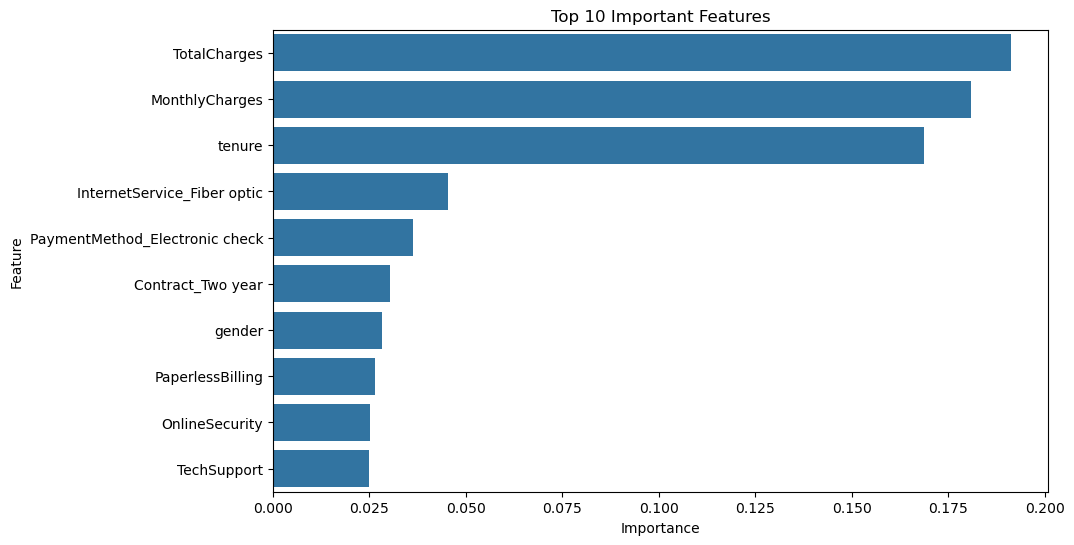

In [135]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

## Business Recommendation

Based on the analysis, the following recommendations can help reduce customer churn:

- Encourage customers to switch from month-to-month contracts to long-term plans by offering discounts or loyalty benefits.
- Focus on customers with shorter tenure by improving onboarding and providing better customer support during the first few months.
- Review pricing strategies for customers with higher monthly charges and provide personalized offers when needed.
- Improve the quality of Fiber Optic services, as customers using this service showed a higher churn rate.
- Encourage customers to use automatic payment methods instead of Electronic Check by providing cashback or small incentives.
- Use the predictive model to identify customers who are at high risk of churning and target them with retention campaigns.

## Final Conclusion

In this project, I analyzed customer data to understand the factors that influence customer churn. After cleaning the data and performing exploratory analysis, I trained and compared three machine learning models.

Among the models, Logistic Regression achieved the highest accuracy of **78.89%**, making it the best-performing model for this dataset.

Working on this project helped me understand the complete machine learning workflow, from data cleaning and visualization to model building, evaluation, and generating business recommendations.

## Save the Trained Model

The final machine learning model is saved using the `joblib` library so it can be loaded later without retraining.

In [136]:
import joblib

joblib.dump(log_model, 'customer_churn_model.pkl')


['customer_churn_model.pkl']